# Off the Chart
## Lyrics and genre across four Billboard Hot 100 chart weeks

**Oluwaseyi Folorunso**  
Python · pandas · APIs · NLP · data quality · visualization

This notebook compares one Billboard Hot 100 chart week from 1965, 1985, 2005, and 2025. It asks whether the genre mix and automated lyric-sentiment scores differ across these four snapshots. It does **not** treat one week as a complete picture of an entire year.

## Executive summary

- The dataset contains **399 chart positions** and **377 songs with retrieved lyrics**.
- VADER and TextBlob both give the 2025 snapshot a lower average score than the three earlier chart weeks.
- The result remains after songs are weighted by chart rank.
- The models agree on the exact positive, neutral, or negative label for only **49% of 2025 songs**, so individual labels should be treated cautiously.
- These results describe four selected chart weeks. They do not prove a continuous historical trend or explain why the language differs.

## 1. Questions and scope

1. How does the broad genre mix compare across the four chart weeks?
2. Do VADER and TextBlob show a similar difference in lyric sentiment?
3. Does the conclusion change after weighting songs by chart rank?
4. Where do missing data, small groups, and model disagreement limit the story?

Exact chart dates are 1965-08-28, 1985-08-24, 2005-08-27, and 2025-05-03.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

candidate = Path.cwd()
PROJECT_ROOT = candidate.parent if candidate.name == "notebooks" else candidate
if not (PROJECT_ROOT / "data" / "processed").exists():
    raise FileNotFoundError("Open this notebook from the repository root or notebooks directory.")

pd.set_option("display.max_columns", 30)
def show_figure(filename):
    image = plt.imread(PROJECT_ROOT / "reports" / "figures" / filename)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(image)
    ax.axis("off")
    plt.show()

print(f"Project root: {PROJECT_ROOT.resolve()}")

Project root located; processed project outputs are available.


## 2. Data sources and preparation

The project combines dated Billboard chart pages, artist-genre results from Spotify and iTunes, and lyrics retrieved from Genius. Full lyrics stay in a local-only folder; the public analysis table contains song metadata, quality flags, sentiment scores, and derived numerical features.

The pipeline keeps source genres, maps them to broad categories, and applies reviewed corrections from a separate table. It also flags likely Genius page text such as “Read More,” missing ranks, duplicate song keys, and incomplete lyric retrieval.

In [2]:
features = pd.read_csv(PROJECT_ROOT / "data/processed/song_features.csv")
audit = pd.read_csv(PROJECT_ROOT / "data/processed/pipeline_audit.csv")
summary = pd.read_csv(PROJECT_ROOT / "data/processed/year_summary.csv")
genres = pd.read_csv(PROJECT_ROOT / "data/processed/genre_summary.csv")

features.shape

(399, 30)

## 3. Data quality first

Coverage is strong, but it is not identical across snapshots. Missing lyrics matter because the songs that could not be retrieved may differ systematically from those that were scored.

In [3]:
(audit[["year", "chart_rows", "missing_chart_positions", "genres_missing",
        "lyrics_retrieved", "lyrics_missing", "lyric_coverage_pct"]]
 .rename(columns={"year": "Year", "chart_rows": "Chart rows",
                  "missing_chart_positions": "Missing ranks", "genres_missing": "Missing genres",
                  "lyrics_retrieved": "Lyrics found", "lyrics_missing": "Lyrics missing",
                  "lyric_coverage_pct": "Coverage (%)"}))

Year,Chart rows,Missing ranks,Missing genres,Lyrics found,Lyrics missing,Coverage (%)
1965,100,0,0,89,11,89.0
1985,100,0,1,94,6,94.0
2005,100,0,0,95,5,95.0
2025,99,1,2,99,0,100.0


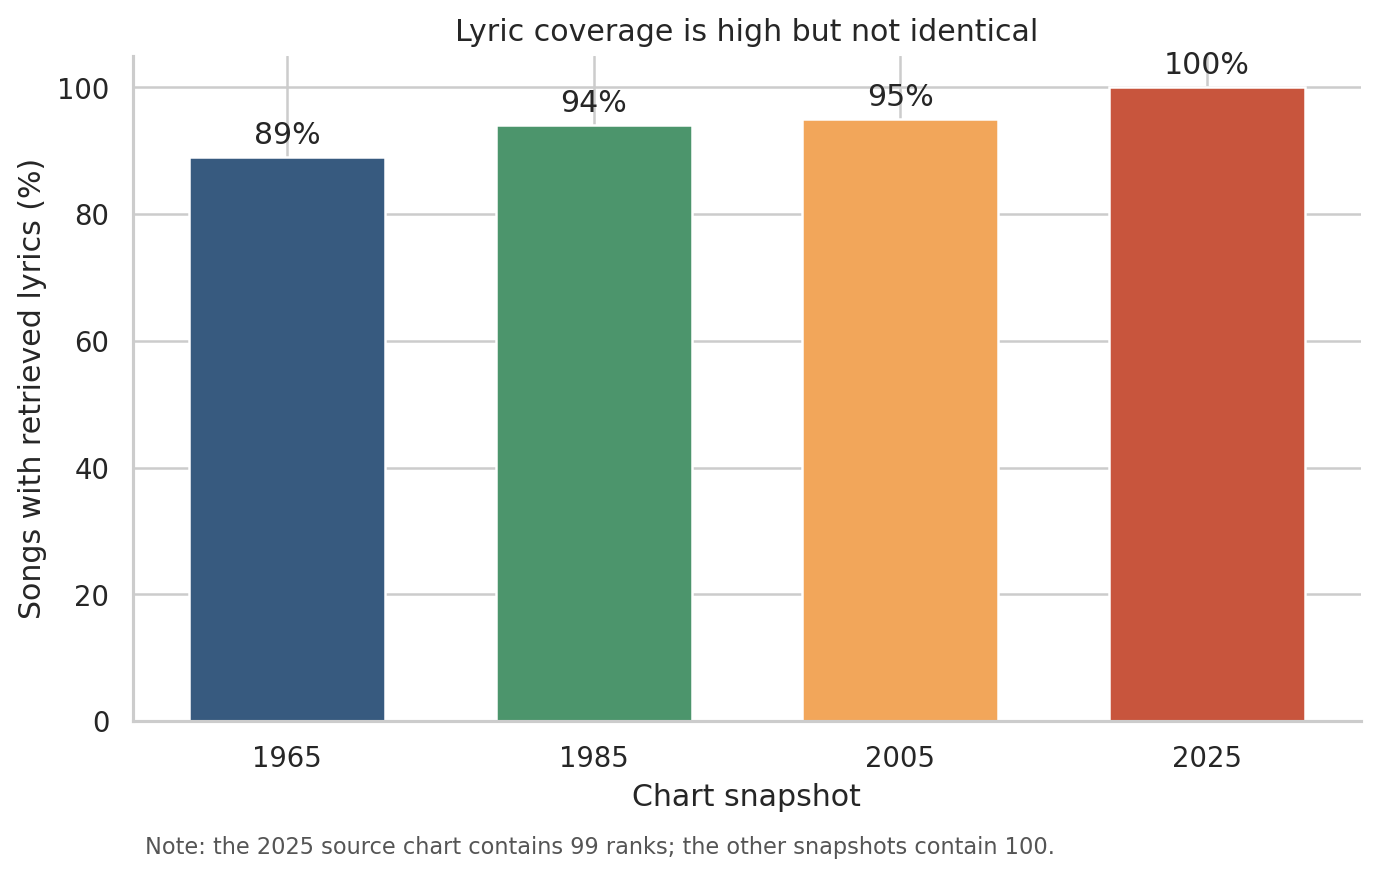

In [4]:
show_figure("01_lyric_coverage.png")

The 1965 chart has the lowest lyric coverage at 89%. The 2025 lyric file covers every song in its source chart, but that chart file has only 99 positions because rank 100 was not captured. The corrected pipeline also documents **26 genre overrides** instead of silently replacing questionable API matches.

## 4. Sentiment method

The reported scores are the original whole-text VADER and TextBlob results. Using two tools helps reveal when a result depends on the model. Scores above 0.05 are labeled positive, scores below -0.05 are labeled negative, and values in between are neutral.

Whole-song VADER scores should be interpreted carefully. VADER was designed for short social-media text, and long lyrics can push its compound score toward -1 or +1. Between 72% and 84% of the songs in each snapshot have an absolute VADER score of at least 0.9. The refactored project includes line-level scoring code for a future rerun, but this notebook does not present unexecuted results from that method.

In [5]:
(summary[["year", "lyrics_scored", "vader_mean", "vader_ci_low", "vader_ci_high",
          "textblob_mean", "textblob_ci_low", "textblob_ci_high", "model_agreement_pct"]]
 .rename(columns={"year": "Year", "lyrics_scored": "Songs scored",
                  "vader_mean": "VADER mean", "vader_ci_low": "VADER CI low",
                  "vader_ci_high": "VADER CI high", "textblob_mean": "TextBlob mean",
                  "textblob_ci_low": "TextBlob CI low", "textblob_ci_high": "TextBlob CI high",
                  "model_agreement_pct": "Model agreement (%)"})
 .round(3))

Year,Songs scored,VADER mean,VADER CI low,VADER CI high,TextBlob mean,TextBlob CI low,TextBlob CI high,Model agreement (%)
1965,89,0.456,0.289,0.611,0.127,0.089,0.165,67.4
1985,94,0.428,0.250,0.595,0.116,0.079,0.151,63.8
2005,95,0.472,0.312,0.624,0.097,0.062,0.130,62.1
2025,99,0.138,-0.042,0.319,0.039,0.007,0.070,49.5


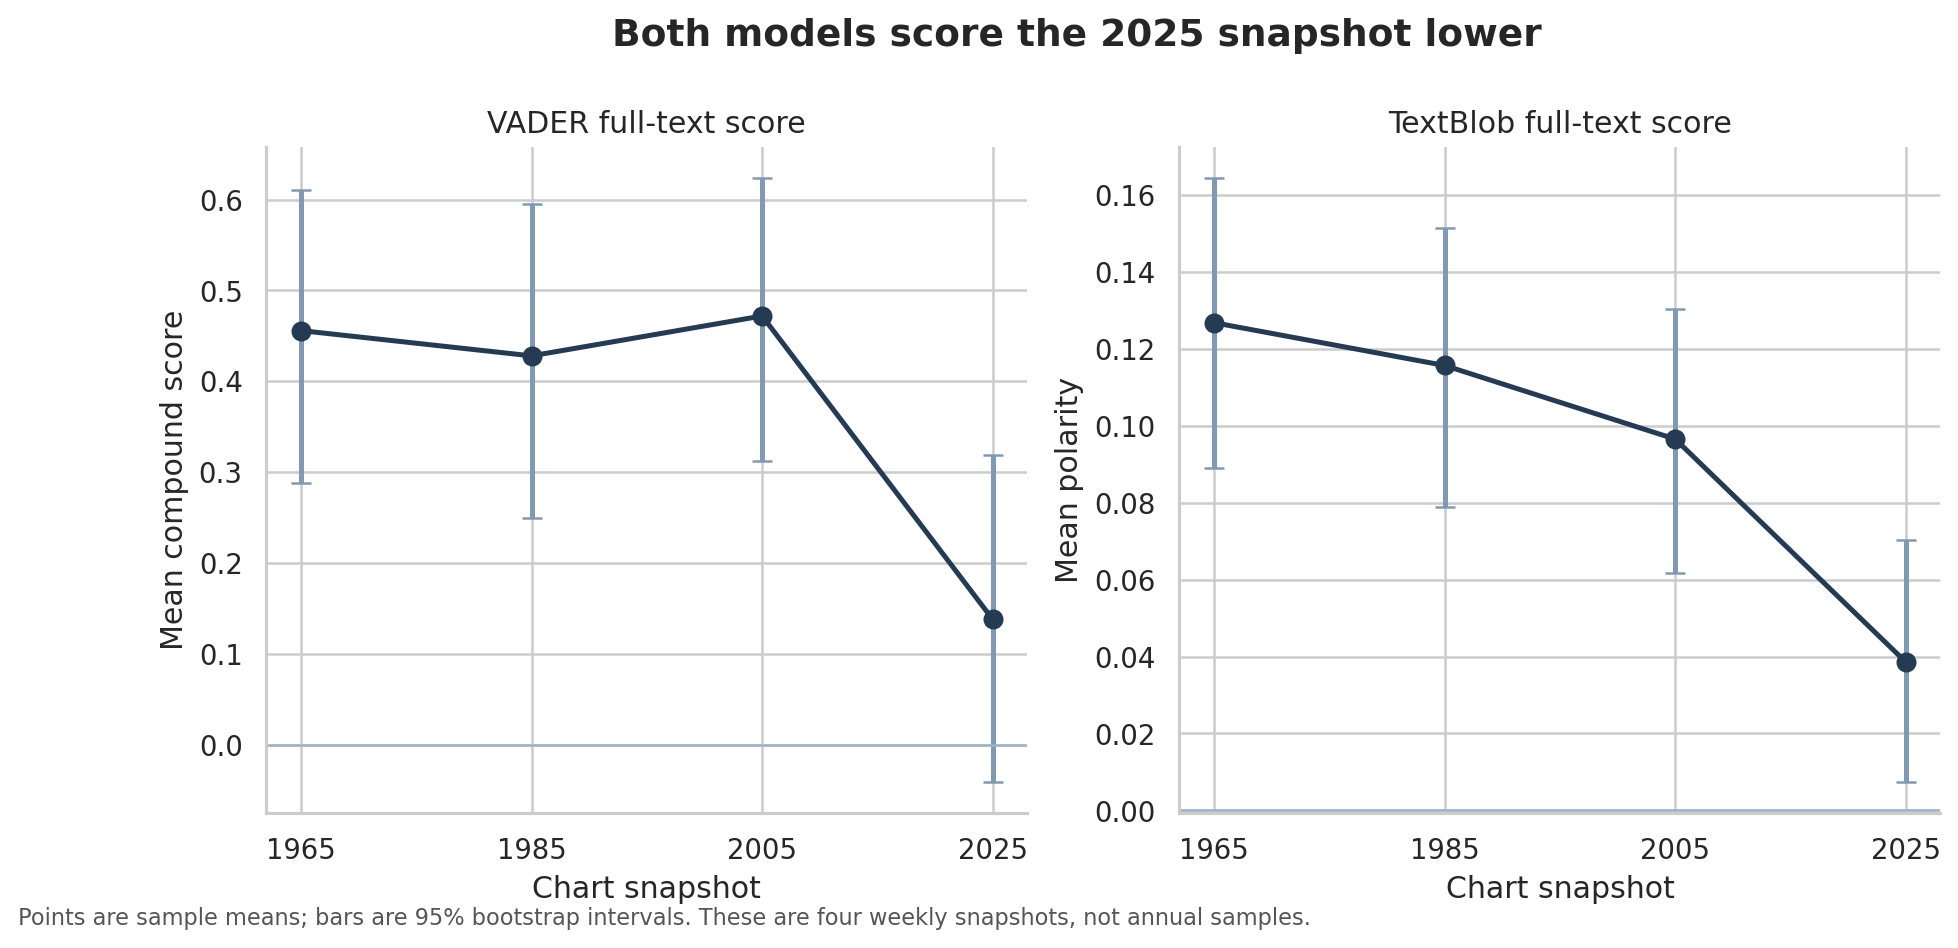

In [6]:
show_figure("02_sentiment_by_year.png")

Both models score the 2025 snapshot lower on average. VADER's 2025 interval is wide and crosses zero, while the TextBlob mean remains slightly positive. When 2025 is compared with the three earlier snapshots pooled together, both bootstrap intervals for the difference stay below zero.

In [7]:
(pd.read_csv(PROJECT_ROOT / "data/processed/sentiment_comparisons.csv")
 .replace({"vader_fulltext_score": "VADER", "textblob_fulltext_score": "TextBlob"})
 [["metric", "mean_difference", "ci_low", "ci_high"]]
 .rename(columns={"metric": "Model", "mean_difference": "2025 difference",
                  "ci_low": "95% CI low", "ci_high": "95% CI high"})
 .round(3))

Model,2025 difference,95% CI low,95% CI high
VADER,-0.314,-0.517,-0.117
TextBlob,-0.074,-0.112,-0.037


### Model disagreement is part of the result

A single sentiment score can look precise even when another reasonable model sees the same text differently. Reporting agreement makes that uncertainty visible.

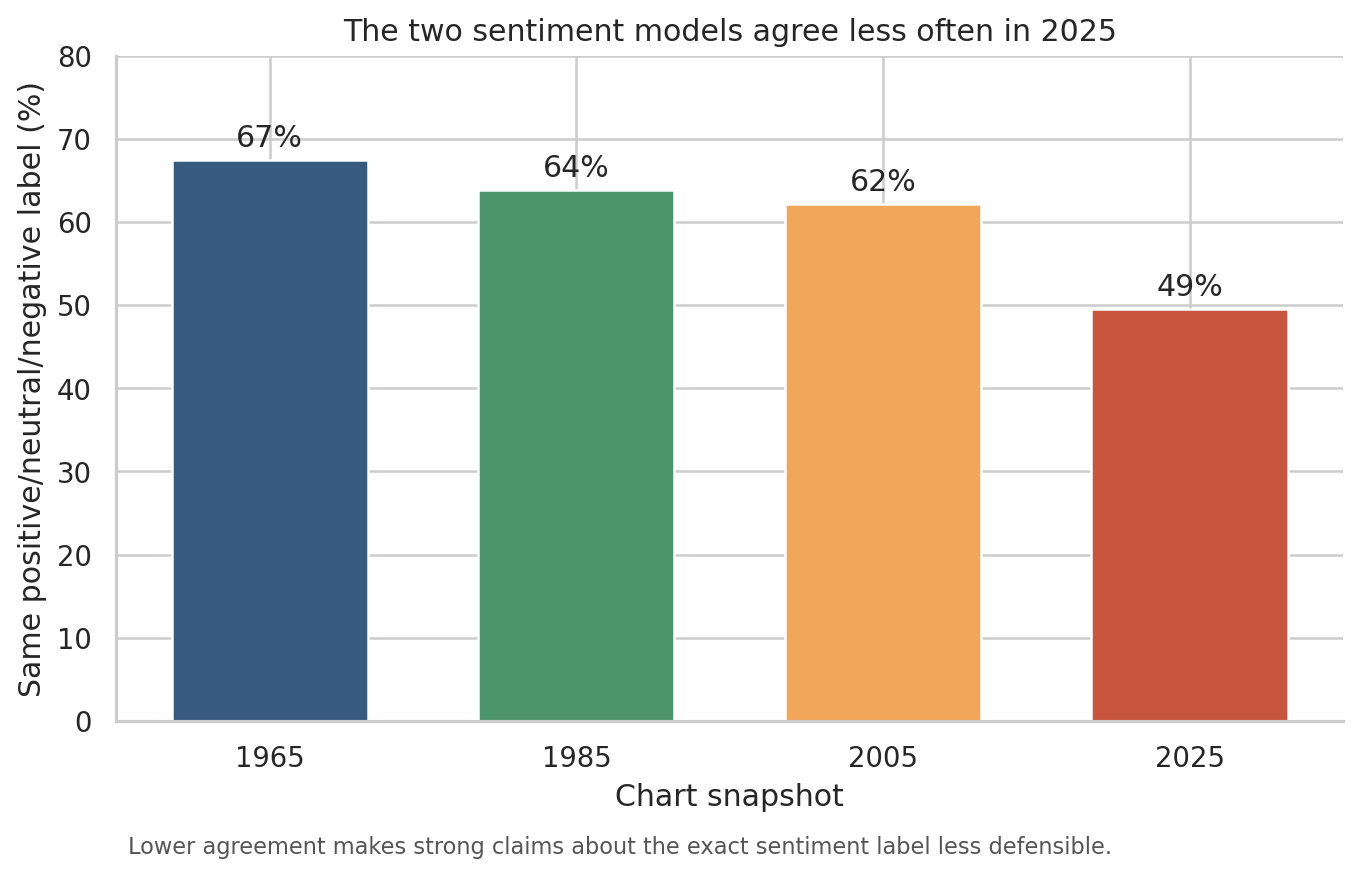

In [8]:
show_figure("03_model_agreement.png")

Agreement falls from 67% in 1965 to 49% in 2025. The lower 2025 averages appear in both models, but the exact song-level labels are not stable enough to support strong claims about every track.

### Rank-weighted sensitivity check

The baseline treats every chart position equally. The sensitivity check gives rank 1 a weight of 100, rank 2 a weight of 99, and so on. The overall pattern remains.

In [9]:
(summary[["year", "vader_mean", "rank_weighted_vader_mean",
          "textblob_mean", "rank_weighted_textblob_mean"]]
 .rename(columns={"year": "Year", "vader_mean": "VADER",
                  "rank_weighted_vader_mean": "Rank-weighted VADER",
                  "textblob_mean": "TextBlob",
                  "rank_weighted_textblob_mean": "Rank-weighted TextBlob"})
 .round(3))

Year,VADER,Rank-weighted VADER,TextBlob,Rank-weighted TextBlob
1965,0.456,0.413,0.127,0.105
1985,0.428,0.419,0.116,0.123
2005,0.472,0.449,0.097,0.108
2025,0.138,0.131,0.039,0.028


## 5. Genre mix

The genre comparison uses stable broad categories rather than dozens of provider-specific labels. Source labels remain available for auditing, and corrections are documented rather than hidden.

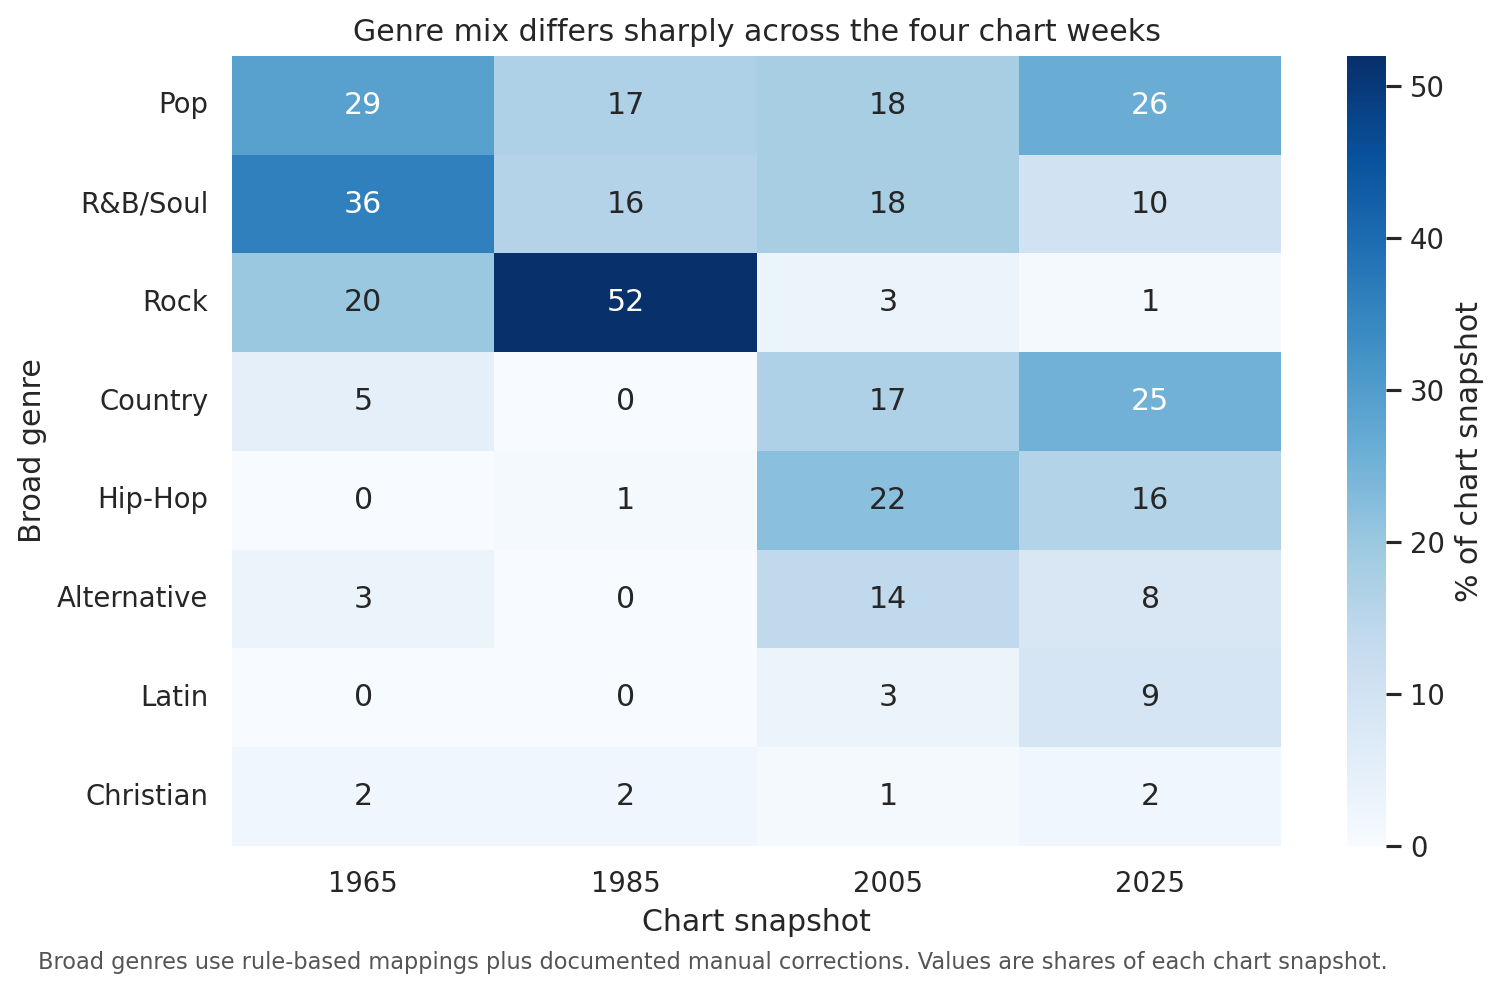

In [10]:
show_figure("04_genre_mix.png")

Rock makes up 52% of the 1985 source chart but 1% of the 2025 chart. Country and Latin make up larger shares of the 2025 snapshot, while Hip-Hop is much more prominent in 2005 and 2025 than in the two earlier files. These are snapshot comparisons, not estimates of annual market share.

### Avoiding small-group headlines

Genre-level sentiment means are shown only when at least five scored songs are available. This prevents a one-song genre from being presented as a reliable pattern. The table below shows the three largest qualifying genres in each snapshot.

In [11]:
(genres[genres["meets_minimum"]]
 .sort_values(["year", "songs"], ascending=[True, False])
 .groupby("year", as_index=False).head(3)
 [["year", "genre", "songs", "vader_mean", "textblob_mean"]]
 .rename(columns={"year": "Year", "genre": "Genre", "songs": "Songs scored",
                  "vader_mean": "VADER mean", "textblob_mean": "TextBlob mean"})
 .round(3))

Year,Genre,Songs scored,VADER mean,TextBlob mean
1965,R&B/Soul,33,0.414,0.152
1965,Pop,24,0.444,0.130
1965,Rock,19,0.303,0.042
1985,Rock,50,0.416,0.084
1985,Pop,17,0.363,0.126
1985,R&B/Soul,14,0.188,0.167
2005,Hip-Hop,22,0.266,0.009
2005,R&B/Soul,18,0.574,0.136
2005,Country,16,0.785,0.104
2025,Pop,26,0.555,0.058


## 6. Limitations

- One chart week cannot represent a full year or establish a 60-year trend.
- The selected dates are not all from the same month, and seasonal releases may affect genre and language.
- Lyric retrieval coverage ranges from 89% to 100%.
- The 2025 source chart is missing rank 100.
- Genre API searches sometimes match the wrong artist; 26 reviewed cases required correction.
- Lexicon sentiment models can miss context, slang, sarcasm, narrative voice, and changes in language across eras.
- The original scoring removed punctuation and capitalization before VADER. The revised cleaner preserves them, but a fresh line-level rerun is still needed.
- Sentiment differences do not explain cultural causes or measure listeners' mental health.

## 7. Next steps

1. Collect every weekly chart for each study year and treat weeks as the sampling unit.
2. Rerun sentiment on cleaned lyric lines and compare aggregation methods.
3. Manually label a stratified sample to measure model accuracy by era and genre.
4. Add a transformer-based model and test whether its conclusions agree with VADER and TextBlob.
5. Investigate how missing lyric records and multilingual songs affect the results.

## Takeaway

The 2025 chart week stands out because both sentiment models score it lower than the earlier snapshots, even after chart-rank weighting. The strongest portfolio lesson, however, is not a dramatic cultural conclusion. It is the value of checking coverage, preserving source values, documenting corrections, comparing models, and matching the claim to what the sample can actually support.